## 1 — Baseline (county-level estimates)
Naive disaggregation. Raw survey county means with no modelling — lower bound on
estimate quality at finer geography. Most counties have 0 or 1 respondents, so
most estimates will be NaN. **This is the point of the baseline** — it
demonstrates why MRP is needed at the county level.

Output: `outputs/estimates/baseline_county_estimates.csv`

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR   = Path("../test_data/processed/")
OUTPUT_DIR = Path("../outputs/")
OUTCOME    = "happening_bin"
MODEL_NAME = "baseline"
STATE_CSV_NAME = "baseline_state_estimates.csv"

STATE_NAMES = {
    "01":"Alabama","02":"Alaska","04":"Arizona","05":"Arkansas","06":"California",
    "08":"Colorado","09":"Connecticut","10":"Delaware","11":"District of Columbia",
    "12":"Florida","13":"Georgia","15":"Hawaii","16":"Idaho","17":"Illinois",
    "18":"Indiana","19":"Iowa","20":"Kansas","21":"Kentucky","22":"Louisiana",
    "23":"Maine","24":"Maryland","25":"Massachusetts","26":"Michigan",
    "27":"Minnesota","28":"Mississippi","29":"Missouri","30":"Montana",
    "31":"Nebraska","32":"Nevada","33":"New Hampshire","34":"New Jersey",
    "35":"New Mexico","36":"New York","37":"North Carolina","38":"North Dakota",
    "39":"Ohio","40":"Oklahoma","41":"Oregon","42":"Pennsylvania",
    "44":"Rhode Island","45":"South Carolina","46":"South Dakota",
    "47":"Tennessee","48":"Texas","49":"Utah","50":"Vermont",
    "51":"Virginia","53":"Washington","54":"West Virginia","55":"Wisconsin",
    "56":"Wyoming",
}

In [2]:
survey = pd.read_csv(DATA_DIR / "climate_survey_responses_recoded.csv",
                     dtype={"state_fips": str, "county_fips": str})
survey = survey.dropna(subset=[OUTCOME]).copy()
survey[OUTCOME] = survey[OUTCOME].astype(float)
print(f"Respondents (non-DK): {len(survey):,}  ({survey[OUTCOME].mean()*100:.1f}% Yes)")
print(f"Distinct counties in survey: {survey['county_fips'].nunique():,}")

Respondents (non-DK): 1,011  (57.9% Yes)
Distinct counties in survey: 403


In [3]:
# Canonical county set from poststrat_county (~3,143 counties)
ps_county = pd.read_csv(DATA_DIR / "poststrat_county.csv",
                        dtype={"county_fips": str, "state_fips": str})
all_counties = (
    ps_county[["county_fips", "state_fips", "county_name"]]
    .drop_duplicates(subset=["county_fips"])
    .reset_index(drop=True)
)
print(f"Counties in poststrat frame: {len(all_counties):,}")

Counties in poststrat frame: 3,143


In [4]:
# Raw survey means by county (unweighted — no ACS poststratification)
county_stats = (
    survey.groupby("county_fips")[OUTCOME]
    .agg(happening_estimate="mean", n_respondents="count")
    .reset_index()
)

estimates = all_counties.merge(county_stats, on="county_fips", how="left")
estimates["n_respondents"] = estimates["n_respondents"].fillna(0).astype(int)
estimates["state_name"] = estimates["state_fips"].map(STATE_NAMES)
estimates = estimates[["county_fips", "state_fips", "state_name", "county_name",
                        "n_respondents", "happening_estimate"]]

n_with_resp  = (estimates["n_respondents"] > 0).sum()
n_zero_resp  = (estimates["n_respondents"] == 0).sum()
n_valid_est  = estimates["happening_estimate"].notna().sum()
print(f"Counties with ≥1 respondent: {n_with_resp:,}  |  zero: {n_zero_resp:,}")
print(f"Counties with non-NaN estimate: {n_valid_est:,}")
valid = estimates.dropna(subset=["happening_estimate"])
if len(valid):
    print(f"Estimate range: [{valid['happening_estimate'].min():.4f}, "
          f"{valid['happening_estimate'].max():.4f}]")
    print(f"Mean (over counties with respondents): {valid['happening_estimate'].mean():.4f}")

Counties with ≥1 respondent: 403  |  zero: 2,740
Counties with non-NaN estimate: 403
Estimate range: [0.0000, 1.0000]
Mean (over counties with respondents): 0.5548


In [5]:
est_dir  = OUTPUT_DIR / "estimates"
diag_dir = OUTPUT_DIR / "diagnostics"
est_dir.mkdir(parents=True, exist_ok=True)
diag_dir.mkdir(parents=True, exist_ok=True)

out_path = est_dir / f"{MODEL_NAME}_county_estimates.csv"
estimates.to_csv(out_path, index=False)
print(f"Saved → {out_path}  (rows: {len(estimates):,})")

diag_path = diag_dir / f"{MODEL_NAME}_county_summary.txt"
with open(diag_path, "w") as f:
    f.write("Baseline County (Naive Disaggregation) — Diagnostic Summary\n")
    f.write("=" * 60 + "\n\n")
    f.write(f"Outcome variable: {OUTCOME}\n")
    f.write(f"Total respondents (non-DK): {len(survey):,}\n")
    f.write(f"Counties total: {len(estimates):,}\n")
    f.write(f"Counties with respondents: {n_with_resp:,}\n")
    f.write(f"Counties with zero respondents: {n_zero_resp:,}\n")
    f.write(f"Counties with non-NaN estimate: {n_valid_est:,}\n\n")
    if len(valid):
        f.write(f"Mean estimate (over valid):   {valid['happening_estimate'].mean():.4f}\n")
        f.write(f"Median estimate (over valid): {valid['happening_estimate'].median():.4f}\n")
        f.write(f"Min:  {valid['happening_estimate'].min():.4f}\n")
        f.write(f"Max:  {valid['happening_estimate'].max():.4f}\n")
print(f"Diagnostics → {diag_path}")

Saved → ../outputs/estimates/baseline_county_estimates.csv  (rows: 3,143)
Diagnostics → ../outputs/diagnostics/baseline_county_summary.txt


Top 10 counties by respondent count:
county_fips state_name       county_name  n_respondents  happening_estimate
      13135    Georgia   Gwinnett County             44            0.568182
      13121    Georgia     Fulton County             35            0.571429
      53033 Washington       King County             27            0.592593
      13089    Georgia     DeKalb County             25            0.560000
      13067    Georgia       Cobb County             20            0.500000
      12086    Florida Miami-Dade County             19            0.473684
      13051    Georgia    Chatham County             15            0.400000
      13057    Georgia   Cherokee County             15            0.600000
      12011    Florida    Broward County             13            0.538462
      53053 Washington     Pierce County             13            0.769231


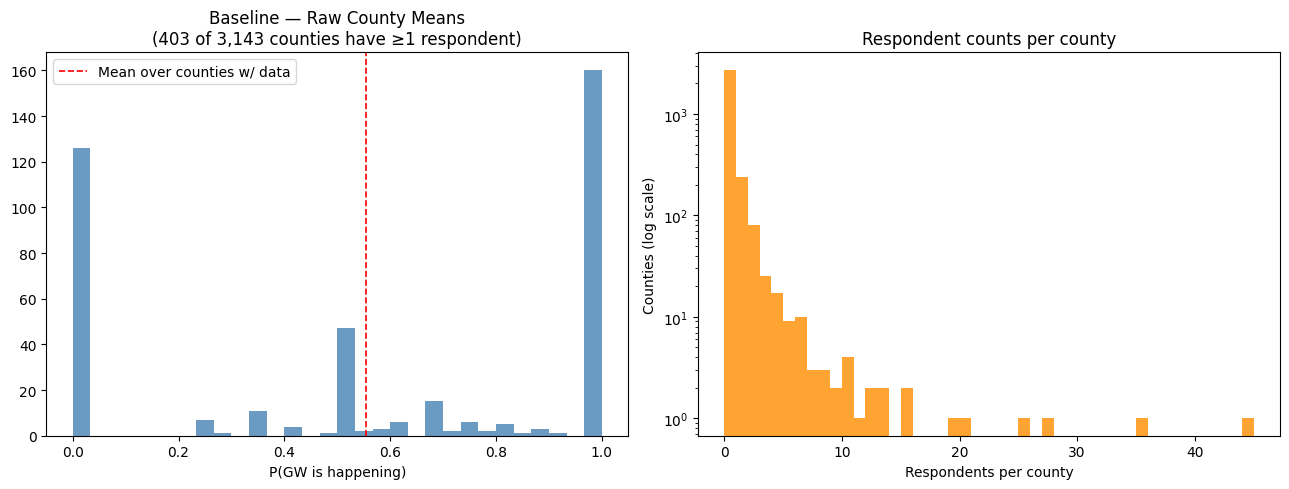

In [6]:
# Top/bottom 10 counties by sample size (since most have ≤1 respondent)
top_n = (
    estimates.dropna(subset=["happening_estimate"])
    .sort_values("n_respondents", ascending=False)
    .head(10)
)
print("Top 10 counties by respondent count:")
print(top_n[["county_fips","state_name","county_name",
             "n_respondents","happening_estimate"]].to_string(index=False))

# Distribution-of-estimates summary
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.hist(valid["happening_estimate"], bins=30, color="steelblue", alpha=0.8)
ax.axvline(valid["happening_estimate"].mean(), color="red", linestyle="--",
           linewidth=1.2, label="Mean over counties w/ data")
ax.set_xlabel("P(GW is happening)")
ax.set_title(f"Baseline — Raw County Means\n({len(valid):,} of {len(estimates):,} counties have ≥1 respondent)")
ax.legend()

ax = axes[1]
ax.hist(estimates["n_respondents"], bins=range(0, int(estimates["n_respondents"].max())+2),
        color="darkorange", alpha=0.8)
ax.set_yscale("log")
ax.set_xlabel("Respondents per county")
ax.set_ylabel("Counties (log scale)")
ax.set_title("Respondent counts per county")

plt.tight_layout()
plt.savefig(est_dir / f"{MODEL_NAME}_county_estimates.png", dpi=150, bbox_inches="tight")
plt.show()